In [1]:
! pip install -U langgraph langchain-anthropic langchain-core langchain-community dotenv

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from typing import Annotated, TypedDict
from langgraph.graph import StateGraph, END
import dotenv
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, ToolMessage
from langchain_anthropic import ChatAnthropic
from langchain_community.tools.tavily_search import TavilySearchResults
import operator
import json


C:\Users\ASUS\AppData\Local\Temp\ipykernel_15224\291269279.py:6: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools.tavily_search import TavilySearchResults


In [3]:
dotenv.load_dotenv()

True

In [4]:
tool = TavilySearchResults(max_results=4)
print(tool)

max_results=4 api_wrapper=TavilySearchAPIWrapper(tavily_api_key=SecretStr('**********'))


C:\Users\ASUS\AppData\Local\Temp\ipykernel_15224\3335602174.py:1: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tool = TavilySearchResults(max_results=4)


In [5]:
tool.__dict__

{'name': 'tavily_search_results_json',
 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. Input should be a search query.',
 'args_schema': langchain_community.tools.tavily_search.tool.TavilyInput,
 'return_direct': False,
 'verbose': False,
 'callbacks': None,
 'tags': None,
 'metadata': None,
 'handle_tool_error': False,
 'handle_validation_error': False,
 'response_format': 'content_and_artifact',
 'extras': None,
 'max_results': 4,
 'search_depth': 'advanced',
 'include_domains': [],
 'exclude_domains': [],
 'include_answer': False,
 'include_raw_content': False,
 'include_images': False,
 'api_wrapper': TavilySearchAPIWrapper(tavily_api_key=SecretStr('**********'))}

In [6]:
class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage],operator.add]

In [7]:
%pip install -U langgraph-checkpoint langgraph-checkpoint-sqlite

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

In [19]:
class Agent:

    def __init__(self,model,tools,checkpointer,system=""):
        self.system = system

        graph = StateGraph(AgentState)
        graph.add_node("llm",self.call_anthropic)
        graph.add_node("action",self.take_action)
        graph.add_conditional_edges("llm",self.exists_action,{True:"action",False:END})
        graph.add_edge("action","llm")

        graph.set_entry_point("llm")
        self.graph = graph.compile(checkpointer=checkpointer)
        self.tools = {t.name: t for t in tools}
        self.model = model.bind_tools(tools)


    def exists_action(self,state:AgentState):
        return len(state["messages"][-1].tool_calls) > 0

    def call_anthropic(self,state:AgentState):
        messages = state['messages']
        if self.system:
            messages = [SystemMessage(content=self.system)] + messages
        message = self.model.invoke(messages)
        return {"messages":[message]}
        
    def take_action(self,state:AgentState):
        tool_calls = state["messages"][-1].tool_calls
        results = []
        for t in tool_calls:
            print(f"Calling: {t}")
            if t["name"] not in self.tools:
                print("\n ....bad tool name....")
                result = "bad tool name, retry"
            else:
                result = self.tools[t["name"]].invoke(t["args"])
            content_str = json.dumps(result) if isinstance(result,(list,dict)) else str(result)
            results.append(ToolMessage(tool_call_id=t['id'],name=t["name"],content=content_str))
            print("Back to the model!")
        return {'messages': results}

In [20]:
prompt = """You are a smart research assistant. Use the search engine to look up information. \
You are allowed to make multiple calls (either together or in sequence). \
Only look up information when you are sure of what you want. \
If you need to look up some information before asking a follow up question, you are allowed to do that!
"""

model = ChatAnthropic(model_name="claude-opus-4-8")

In [21]:
abot = Agent(model,[tool],system=prompt,checkpointer=memory)

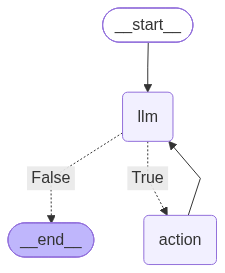

In [22]:
from IPython.display import Image, display
display(Image(abot.graph.get_graph().draw_mermaid_png()))

In [24]:
thread = {"configurable": {"thread_id": "1"}}

In [25]:
messages = [HumanMessage(content="What is the weather in sf?")]
for event in  abot.graph.stream({"messages": messages},thread):
        for v in event.values():
                print(v)

{'messages': [AIMessage(content=[{'text': "I'll search for the current weather in San Francisco for you.", 'type': 'text'}, {'id': 'toolu_01CFe6QyLtxMEjirGQ8QpweM', 'caller': {'type': 'direct'}, 'input': {'query': 'current weather in San Francisco'}, 'name': 'tavily_search_results_json', 'type': 'tool_use'}], additional_kwargs={}, response_metadata={'id': 'msg_011CdKnCNAGuBxgRr97pLDcL', 'container': None, 'model': 'claude-opus-4-8', 'stop_details': None, 'stop_reason': 'tool_use', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'inference_geo': 'global', 'input_tokens': 514, 'output_tokens': 80, 'output_tokens_details': {'thinking_tokens': 0}, 'server_tool_use': None, 'service_tier': 'standard'}, 'model_name': 'claude-opus-4-8', 'model_provider': 'anthropic'}, id='lc_run--019f9119-6db9-75d2-8381-fc8d48b77fb3-0', tool_calls=[{'name': 'tavily_search_results

In [26]:
messages = [HumanMessage(content="What about la?")]
for event in  abot.graph.stream({"messages": messages},thread):
        for v in event.values():
                print(v)

{'messages': [AIMessage(content=[{'text': "I'll search for the current weather in Los Angeles for you.", 'type': 'text'}, {'id': 'toolu_01N6CJ6NnBvJXu4VfuRFuYAv', 'caller': {'type': 'direct'}, 'input': {'query': 'current weather in Los Angeles'}, 'name': 'tavily_search_results_json', 'type': 'tool_use'}], additional_kwargs={}, response_metadata={'id': 'msg_011CdKnEocmp7cgJXZxFebxS', 'container': None, 'model': 'claude-opus-4-8', 'stop_details': None, 'stop_reason': 'tool_use', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'inference_geo': 'global', 'input_tokens': 8464, 'output_tokens': 82, 'output_tokens_details': {'thinking_tokens': 0}, 'server_tool_use': None, 'service_tier': 'standard'}, 'model_name': 'claude-opus-4-8', 'model_provider': 'anthropic'}, id='lc_run--019f9119-ef05-7a41-9371-5af2afd4241c-0', tool_calls=[{'name': 'tavily_search_results_js

In [27]:
messages = [HumanMessage(content="Which one is warmer?")]
thread = {"configurable": {"thread_id": "2"}}
for event in  abot.graph.stream({"messages": messages},thread):
        for v in event.values():
                print(v)

{'messages': [AIMessage(content='I\'d be happy to help you compare temperatures! However, I need a bit more information to answer your question accurately.\n\nCould you please tell me **which two (or more) things you\'d like to compare**? For example:\n\n- **Two cities or locations** (e.g., "Which is warmer, Miami or Los Angeles?")\n- **Two dates or times** (e.g., "Which is warmer, today or tomorrow?")\n- **Two materials or objects** (e.g., "Which is warmer, wool or cotton?")\n\nOnce you let me know what you\'d like to compare, I can look up the relevant information for you!', additional_kwargs={}, response_metadata={'id': 'msg_011CdKnLH2vcniySowtKKkzF', 'container': None, 'model': 'claude-opus-4-8', 'stop_details': None, 'stop_reason': 'end_turn', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'inference_geo': 'global', 'input_tokens': 513, 'output_toke

In [28]:
messages = [HumanMessage(content="Which one is warmer?")]
thread = {"configurable": {"thread_id": "1"}}
for event in  abot.graph.stream({"messages": messages},thread):
        for v in event.values():
                print(v)

{'messages': [AIMessage(content="**Los Angeles is warmer** — by a significant margin! 🌡️\n\nHere's the comparison for today (July 23, 2026):\n\n| | San Francisco | Los Angeles |\n|---|---|---|\n| **High** | ~19°C (66°F) | ~30–33°C (86–90°F) |\n| **Low** | ~14°C (57°F) | ~18–23°C (64–73°F) |\n| **Conditions** | Cool, misty/cloudy | Hot, sunny |\n\nLA is roughly **11–14°C (20–24°F) warmer** than SF today. This is pretty typical — San Francisco's coastal fog and marine layer keep it cool year-round, while LA enjoys much hotter, sunnier summer weather. 😎", additional_kwargs={}, response_metadata={'id': 'msg_011CdKnMWhEFnmusKpVWYhq6', 'container': None, 'model': 'claude-opus-4-8', 'stop_details': None, 'stop_reason': 'end_turn', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'inference_geo': 'global', 'input_tokens': 13248, 'output_tokens': 250, 'output_token

In [32]:
memory = MemorySaver()
abot = Agent(model,[tool],memory,prompt)

In [33]:
messages = [HumanMessage(content="What is the weather in SF?")]
thread = {"configurable": {"thread_id": "3"}}

async for event in abot.graph.astream_events({"messages":messages},thread,version="v2"):
    kind = event["event"]
    if kind == "on_chat_model_stream":
        content = event["data"]["chunk"].content
        if content:
            print(content,end="|",flush=True)

[{'text': "I'll look up the current", 'type': 'text', 'index': 0}]|[{'text': ' weather in San Francisco for you.', 'type': 'text', 'index': 0}]|[{'id': 'toolu_01N6pm4cEBY631sYNMQm5Cij', 'caller': {'type': 'direct'}, 'input': {}, 'name': 'tavily_search_results_json', 'type': 'tool_use', 'index': 1}]|[{'partial_json': '', 'type': 'input_json_delta', 'index': 1}]|[{'partial_json': '{"', 'type': 'input_json_delta', 'index': 1}]|[{'partial_json': 'query": ', 'type': 'input_json_delta', 'index': 1}]|[{'partial_json': '"curr', 'type': 'input_json_delta', 'index': 1}]|[{'partial_json': 'ent weath', 'type': 'input_json_delta', 'index': 1}]|[{'partial_json': 'er in Sa', 'type': 'input_json_delta', 'index': 1}]|[{'partial_json': 'n F', 'type': 'input_json_delta', 'index': 1}]|[{'partial_json': 'ranci', 'type': 'input_json_delta', 'index': 1}]|[{'partial_json': 'sc', 'type': 'input_json_delta', 'index': 1}]|[{'partial_json': 'o"}', 'type': 'input_json_delta', 'index': 1}]|Calling: {'name': 'tavily